# Experiment 09 – Model Evaluation, Bayesian Inference and Explainable AI

## Aim

To apply model evaluation, Bayesian inference concepts, and explainable AI techniques to interpret and understand machine learning predictions on the Pima Indians Diabetes Dataset.

## Objectives

1. Apply model evaluation and Bayesian concepts to analyze the reliability of machine learning predictions.
2. Apply explainable AI techniques to interpret model predictions and identify important features influencing the results.

In [1]:
!pip install -q shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from google.colab import files
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    brier_score_loss,
    classification_report
)
from sklearn.calibration import (
    calibration_curve,
    CalibrationDisplay
)
sns.set_theme(style="whitegrid")

In [3]:
uploaded = files.upload()
df = pd.read_csv("diabetes.csv")
print("Dataset loaded successfully.")
display(df.head())

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [5]:
df_processed = df.copy()
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df_processed[invalid_columns] = df_processed[invalid_columns].replace(
    0, np.nan
)
for column in invalid_columns:
    df_processed[column] = df_processed[column].fillna(
        df_processed[column].median()
    )
print("Invalid values handled successfully.")
print("\nRemaining missing values:")
print(df_processed.isnull().sum())

Invalid values handled successfully.

Remaining missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]
X = df_processed[features]
y = df_processed["Outcome"]
print("Number of features:", len(features))
print("Target variable: Outcome")

Number of features: 8
Target variable: Outcome


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 8)
Testing set: (154, 8)


In [8]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-diabetic", "Diabetic"]
    )
)

Accuracy: 0.7078
F1-Score: 0.5714

Classification Report:
              precision    recall  f1-score   support

Non-diabetic       0.77      0.79      0.78       100
    Diabetic       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1"],
    return_train_score=False
)
cv_accuracy = cv_results["test_accuracy"]
cv_f1 = cv_results["test_f1"]
print("5-Fold Cross-Validation Results")
print("--------------------------------")
print("Accuracy scores:", np.round(cv_accuracy, 4))
print("Mean Accuracy:", round(cv_accuracy.mean(), 4))
print("\nF1-Score scores:", np.round(cv_f1, 4))
print("Mean F1-Score:", round(cv_f1.mean(), 4))

5-Fold Cross-Validation Results
--------------------------------
Accuracy scores: [0.7662 0.8247 0.7727 0.7582 0.7516]
Mean Accuracy: 0.7747

F1-Score scores: [0.6327 0.7033 0.6465 0.6186 0.6545]
Mean F1-Score: 0.6511


In [11]:
brier_score = brier_score_loss(
    y_test,
    y_prob
)

print(f"Brier Score: {brier_score:.4f}")

Brier Score: 0.1692


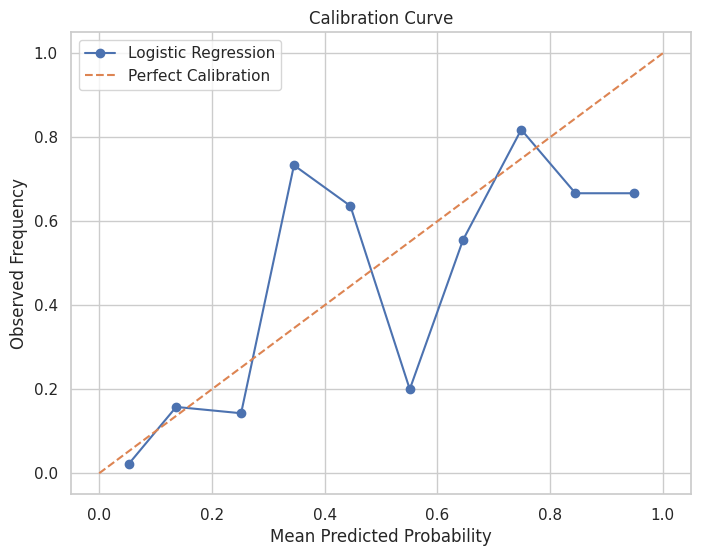

In [12]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)
plt.figure(figsize=(8, 6))
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [13]:
cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "F1-Score"],
    "Mean": [
        cv_accuracy.mean(),
        cv_f1.mean()
    ],
    "Standard Deviation": [
        cv_accuracy.std(),
        cv_f1.std()
    ]
})
display(cv_summary)

,Metric,Mean,Standard Deviation
0,Accuracy,0.774688,0.025994
1,F1-Score,0.651103,0.028835


In [14]:
# Transform the test data using the scaler inside the pipeline
X_test_scaled = model.named_steps["scaler"].transform(X_test)
# Create a SHAP explainer for the logistic regression classifier
classifier = model.named_steps["classifier"]
explainer = shap.LinearExplainer(
    classifier,
    model.named_steps["scaler"].transform(X_train)
)
shap_values = explainer(X_test_scaled)
print("SHAP explanation generated successfully.")

SHAP explanation generated successfully.


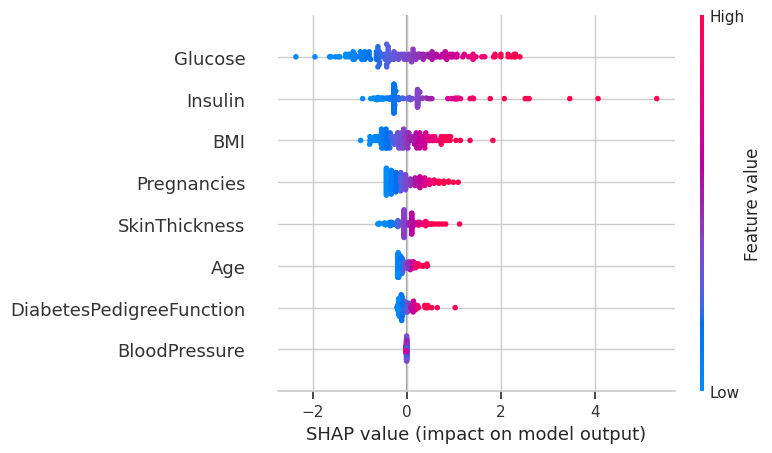

In [15]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=features
)

In [16]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    "Feature": features,
    "Mean Absolute SHAP Value": mean_abs_shap
}).sort_values(
    "Mean Absolute SHAP Value",
    ascending=False
)
display(shap_importance)

,Feature,Mean Absolute SHAP Value
1,Glucose,0.804222
4,Insulin,0.501050
5,BMI,0.384932
0,Pregnancies,0.304877
3,SkinThickness,0.208257
7,Age,0.136612
6,DiabetesPedigreeFunction,0.130258
2,BloodPressure,0.003048


Actual Outcome: 0
Predicted Outcome: 0
Predicted Probability: 0.4774


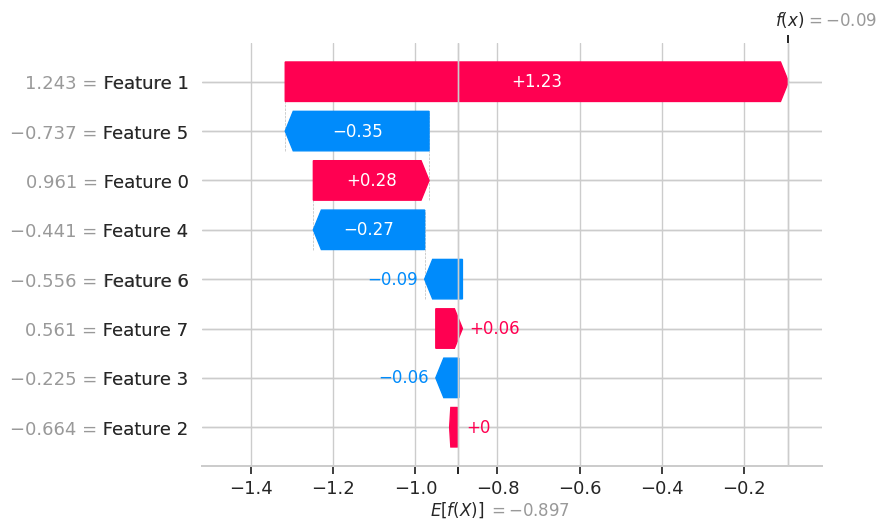

In [17]:
sample_index = 0
print("Actual Outcome:", y_test.iloc[sample_index])
print("Predicted Outcome:", y_pred[sample_index])
print("Predicted Probability:", round(y_prob[sample_index], 4))
shap.plots.waterfall(
    shap_values[sample_index],
    max_display=10
)

## Conclusion

The Logistic Regression classification model was evaluated using a stratified 5-fold cross-validation procedure. Accuracy and F1-score were used to measure classification performance across the folds.

The Brier Score and calibration curve were used to examine the reliability of the predicted probabilities. SHAP was used to explain model predictions and identify the features that contributed most to the model's output.

The experiment demonstrated that evaluating a machine learning model involves not only measuring predictive performance, but also examining probability reliability and understanding the factors influencing individual predictions.